# Predictive Power Rankings

Build predictive power rankings for college football teams across Big Ten, SEC, Big 12, and ACC conferences.
Rankings use a weighted composite score derived from SP+ metrics, recruiting class strength, and talent data.

**Prerequisites**: Run the data pipeline first:
1. `python get_recruit_data.py`
2. `python get_roster_data.py`
3. `python merge_roster_rankings.py`
4. `python get_advanced_metrics.py`

In [34]:
import ast
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import config

## 1. Data Loading & Parsing

In [35]:
# Load advanced metrics
adv = pd.read_csv('data/advanced_metrics.csv')
print(f"Advanced metrics: {adv.shape}")
adv.head(2)

Advanced metrics: (737, 11)


,year,team,conference,rating,ranking,secondOrderWins,sos,offense,defense,specialTeams,talent
0,2015,Ohio State,Big Ten,29.5,1.0,11.8,0.873,"{'ranking': 12, 'rating': 41.3, 'success': 120...","{'ranking': 6, 'rating': 13.5, 'success': 122....",{'rating': 1.8},907.32
1,2015,Alabama,SEC,29.0,2.0,13.1,0.777,"{'ranking': 23, 'rating': 37.7, 'success': 110...","{'ranking': 1, 'rating': 9.1, 'success': 148.9...",{'rating': 0.4},981.90


In [36]:
# Parse stringified dict columns into flat columns
def parse_dict_column(df, col, prefix):
    """Parse a stringified dict column into flat columns with a prefix."""
    parsed = df[col].apply(ast.literal_eval)
    normalized = pd.json_normalize(parsed)
    normalized.columns = [f"{prefix}_{c}" for c in normalized.columns]
    return normalized

off_cols = parse_dict_column(adv, 'offense', 'off')
def_cols = parse_dict_column(adv, 'defense', 'def')
st_cols = parse_dict_column(adv, 'specialTeams', 'st')

adv_flat = pd.concat([adv.drop(columns=['offense', 'defense', 'specialTeams']), off_cols, def_cols, st_cols], axis=1)
print(f"Flattened columns: {adv_flat.shape[1]}")
adv_flat.head(2)

Flattened columns: 30


,year,team,conference,rating,ranking,secondOrderWins,sos,talent,off_ranking,off_rating,...,def_success,def_explosiveness,def_rushing,def_passing,def_standardDowns,def_passingDowns,def_havoc.total,def_havoc.frontSeven,def_havoc.db,st_rating
0,2015,Ohio State,Big Ten,29.5,1.0,11.8,0.873,907.32,12,41.3,...,122.2,111.6,114.6,117.3,115.8,116.5,0.166,0.120,0.046,1.8
1,2015,Alabama,SEC,29.0,2.0,13.1,0.777,981.90,23,37.7,...,148.9,96.1,140.6,117.5,126.7,111.4,0.232,0.145,0.087,0.4


In [37]:
# Load merged roster data and aggregate recruiting stats per team per year
roster_path = Path('data/merged_rosters')
roster_files = sorted(roster_path.glob('*.csv')) if roster_path.exists() else []

if roster_files:
    roster_agg_list = []
    for f in roster_files:
        rdf = pd.read_csv(f)
        year = int(f.stem.split('_')[-1]) if f.stem[-4:].isdigit() else int(f.stem[-4:])
        # Group by team
        for team, grp in rdf.groupby('team'):
            rated = grp['stars'].dropna()
            roster_agg_list.append({
                'year': year,
                'team': team,
                'avg_stars': rated.mean() if len(rated) > 0 else np.nan,
                'five_star_count': (rated == 5).sum(),
                'four_star_count': (rated == 4).sum(),
                'rated_player_pct': len(rated) / len(grp) if len(grp) > 0 else 0
            })
    roster_agg = pd.DataFrame(roster_agg_list)
    print(f"Roster aggregates: {roster_agg.shape}")
    display(roster_agg.head())
else:
    print("No merged roster files found. Run the roster pipeline first.")
    print("Proceeding without player-level recruiting features.")
    roster_agg = pd.DataFrame(columns=['year', 'team', 'avg_stars', 'five_star_count', 'four_star_count', 'rated_player_pct'])

No merged roster files found. Run the roster pipeline first.
Proceeding without player-level recruiting features.


## 2. Feature Engineering

In [38]:
# Select features for the composite model
feature_cols = [
    'rating',           # SP+ overall rating
    'off_rating',       # SP+ offensive rating
    'def_rating',       # SP+ defensive rating (lower = better, will invert)
    'off_success',
    'off_explosiveness',
    'off_rushing',
    'off_passing',
    'def_success',
    'def_explosiveness',
    'def_rushing',
    'def_passing',
    'def_havoc.total',
    'st_rating',
    'talent',
    'sos',
]

# Merge roster aggregates if available
df = adv_flat.copy()
if not roster_agg.empty:
    df = df.merge(roster_agg, on=['year', 'team'], how='left')
    feature_cols += ['avg_stars', 'five_star_count', 'four_star_count', 'rated_player_pct']

# Add prior-year SP+ rating as a lag feature
df = df.sort_values(['team', 'year'])
df['prior_year_rating'] = df.groupby('team')['rating'].shift(1)
feature_cols.append('prior_year_rating')

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
df[['year', 'team', 'conference'] + feature_cols].head()

Feature columns (16): ['rating', 'off_rating', 'def_rating', 'off_success', 'off_explosiveness', 'off_rushing', 'off_passing', 'def_success', 'def_explosiveness', 'def_rushing', 'def_passing', 'def_havoc.total', 'st_rating', 'talent', 'sos', 'prior_year_rating']


,year,team,conference,rating,off_rating,def_rating,off_success,off_explosiveness,off_rushing,off_passing,def_success,def_explosiveness,def_rushing,def_passing,def_havoc.total,st_rating,talent,sos,prior_year_rating
1,2015,Alabama,SEC,29.0,37.7,9.1,110.8,102.4,108.1,108.2,148.9,96.1,140.6,117.5,0.232,0.4,981.90,0.777,NaN
67,2016,Alabama,SEC,31.7,40.0,8.6,114.1,108.6,119.1,106.2,150.0,107.4,157.0,122.0,0.210,0.4,982.66,0.787,29.0
134,2017,Alabama,SEC,33.5,38.7,5.6,114.8,105.7,113.9,109.9,132.9,118.5,135.5,122.5,0.212,0.4,997.57,0.842,31.7
201,2018,Alabama,SEC,36.3,50.9,14.2,136.2,117.6,123.2,132.4,133.4,98.1,129.3,113.7,0.212,-0.4,978.54,0.795,33.5
270,2019,Alabama,SEC,32.4,47.7,14.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.7,984.96,NaN,36.3


In [39]:
# Check feature coverage
print("Missing values per feature:")
print(df[feature_cols].isnull().sum())
print(f"\nTotal rows: {len(df)}")

Missing values per feature:
rating                 0
off_rating             0
def_rating             0
off_success          469
off_explosiveness    469
off_rushing          469
off_passing          469
def_success          469
def_explosiveness    469
def_rushing          469
def_passing          469
def_havoc.total      469
st_rating            134
talent                 0
sos                  469
prior_year_rating     67
dtype: int64

Total rows: 737


## 3. Composite Ranking Model

In [40]:
def normalize_features(df, feature_cols):
    """Min-max normalize features to 0-100 within each year."""
    normalized = df.copy()
    for col in feature_cols:
        if col not in normalized.columns:
            continue
        for year in normalized['year'].unique():
            mask = normalized['year'] == year
            vals = normalized.loc[mask, col].astype(float)
            vmin, vmax = vals.min(), vals.max()
            if vmax > vmin:
                normalized.loc[mask, col] = (vals - vmin) / (vmax - vmin) * 100
            else:
                normalized.loc[mask, col] = 50.0
    return normalized

df_norm = normalize_features(df, feature_cols)
df_norm[['year', 'team'] + feature_cols].describe()

,year,rating,off_rating,def_rating,off_success,off_explosiveness,off_rushing,off_passing,def_success,def_explosiveness,def_rushing,def_passing,def_havoc.total,st_rating,talent,sos,prior_year_rating
count,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000
mean,2020.000000,50.136417,49.120095,51.114678,49.551668,48.013192,48.643018,48.934427,45.490174,50.044334,44.426301,48.143395,48.589333,54.087766,40.587055,50.456598,50.255106
std,3.164425,22.391275,22.866506,23.148845,12.123915,15.046273,14.277812,12.546572,14.174452,13.525685,13.983726,13.296712,12.657420,24.677766,24.610615,12.901196,21.296481
min,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,34.873950,33.676976,34.983498,50.000000,50.000000,50.000000,50.000000,46.034215,50.000000,42.148760,50.000000,50.000000,40.000000,21.878759,50.000000,36.818182
50%,2020.000000,50.442478,50.000000,51.886792,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,35.683448,50.000000,50.000000
75%,2023.000000,65.748031,65.064103,67.241379,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,71.698113,59.339899,50.000000,64.403292
max,2025.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [41]:
# Correlation analysis: which features correlate most with SP+ overall rating?
# Use un-normalized data for this
corr_target = df[feature_cols].corrwith(df['rating']).sort_values(ascending=False)
print("Feature correlations with SP+ overall rating:")
print(corr_target.to_string())

Feature correlations with SP+ overall rating:
rating               1.000000
off_rating           0.757916
off_success          0.738382
prior_year_rating    0.684690
off_passing          0.684524
def_passing          0.678610
def_success          0.672935
def_rushing          0.619954
talent               0.572443
off_rushing          0.565602
def_havoc.total      0.514668
off_explosiveness    0.381548
st_rating            0.295943
def_explosiveness    0.280557
sos                 -0.292250
def_rating          -0.742377


In [42]:
# Define composite weights
# SP+ overall is the strongest predictor; recruiting and talent provide independent signal
weights = {
    'rating': 0.30,             # SP+ overall â€” strongest predictor
    'off_rating': 0.08,
    'def_rating': 0.08,
    'talent': 0.12,             # Talent composite
    'prior_year_rating': 0.10,  # Returning production proxy
    'off_success': 0.04,
    'def_success': 0.04,
    'off_explosiveness': 0.02,
    'def_explosiveness': 0.02,
    'def_havoc.total': 0.03,
    'st_rating': 0.02,
    'sos': 0.05,
}

# Add recruiting weights if available
if 'avg_stars' in df_norm.columns and df_norm['avg_stars'].notna().any():
    weights['avg_stars'] = 0.05
    weights['five_star_count'] = 0.02
    weights['four_star_count'] = 0.02
    weights['rated_player_pct'] = 0.01
    # Rebalance: reduce SP+ overall slightly
    weights['rating'] = 0.20

# Normalize weights to sum to 1
total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}
print(f"Weights (sum={sum(weights.values()):.2f}):")
for k, v in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.3f}")

Weights (sum=1.00):
  rating: 0.333
  talent: 0.133
  prior_year_rating: 0.111
  off_rating: 0.089
  def_rating: 0.089
  sos: 0.056
  off_success: 0.044
  def_success: 0.044
  def_havoc.total: 0.033
  off_explosiveness: 0.022
  def_explosiveness: 0.022
  st_rating: 0.022


In [43]:
# Compute composite score
df_norm['composite_score'] = 0.0
for feat, w in weights.items():
    if feat in df_norm.columns:
        df_norm['composite_score'] += df_norm[feat].fillna(50.0) * w

# Rank nationally and by conference
df_norm['national_rank'] = df_norm.groupby('year')['composite_score'].rank(ascending=False, method='min').astype(int)
df_norm['conference_rank'] = df_norm.groupby(['year', 'conference'])['composite_score'].rank(ascending=False, method='min').astype(int)

print("Top 10 nationally (most recent year):")
latest_year = df_norm['year'].max()
top10 = df_norm[df_norm['year'] == latest_year].nsmallest(10, 'national_rank')[['year', 'team', 'conference', 'composite_score', 'national_rank']]
display(top10)

Top 10 nationally (most recent year):


,year,team,conference,composite_score,national_rank
671,2025,Ohio State,Big Ten,75.186321,1
674,2025,Georgia,SEC,73.703832,2
673,2025,Oregon,Big Ten,72.572518,3
675,2025,Ole Miss,SEC,70.137168,4
683,2025,Penn State,Big Ten,66.947226,5
685,2025,Texas,SEC,66.289297,6
687,2025,Tennessee,SEC,65.924509,7
678,2025,Texas A&M,SEC,65.679208,8
670,2025,Indiana,Big Ten,65.226663,9
677,2025,Miami,ACC,64.304383,10


In [ ]:
# Ridge regression to learn feature importances from data
# Uses temporal train/test split to avoid in-sample circularity
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Use SP+ rating as the target — train on sub-metrics that compose it
# Note: off_rating + def_rating are components of rating, so high R² is
# partly tautological. This is for feature importance exploration, not prediction.
train_feats = [c for c in feature_cols if c != 'rating']
train_df = df.dropna(subset=train_feats + ['rating'])

# Temporal split: train on years <= 2023, test on 2024-2025
train_mask = train_df['year'] <= 2023
test_mask = train_df['year'] > 2023

X_tr = train_df.loc[train_mask, train_feats].values
y_tr = train_df.loc[train_mask, 'rating'].values
X_te = train_df.loc[test_mask, train_feats].values
y_te = train_df.loc[test_mask, 'rating'].values

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_scaled, y_tr)

print(f"Ridge R² (train, ≤2023): {ridge.score(X_tr_scaled, y_tr):.3f}")
print(f"Ridge R² (test, 2024-2025): {ridge.score(X_te_scaled, y_te):.3f}")
print("\nLearned feature importances (|coef|):")
coefs = pd.Series(np.abs(ridge.coef_), index=train_feats).sort_values(ascending=False)
print(coefs.to_string())
print("\nNote: High R² expected because off_rating and def_rating are sub-components of rating.")

## 4. Visualizations

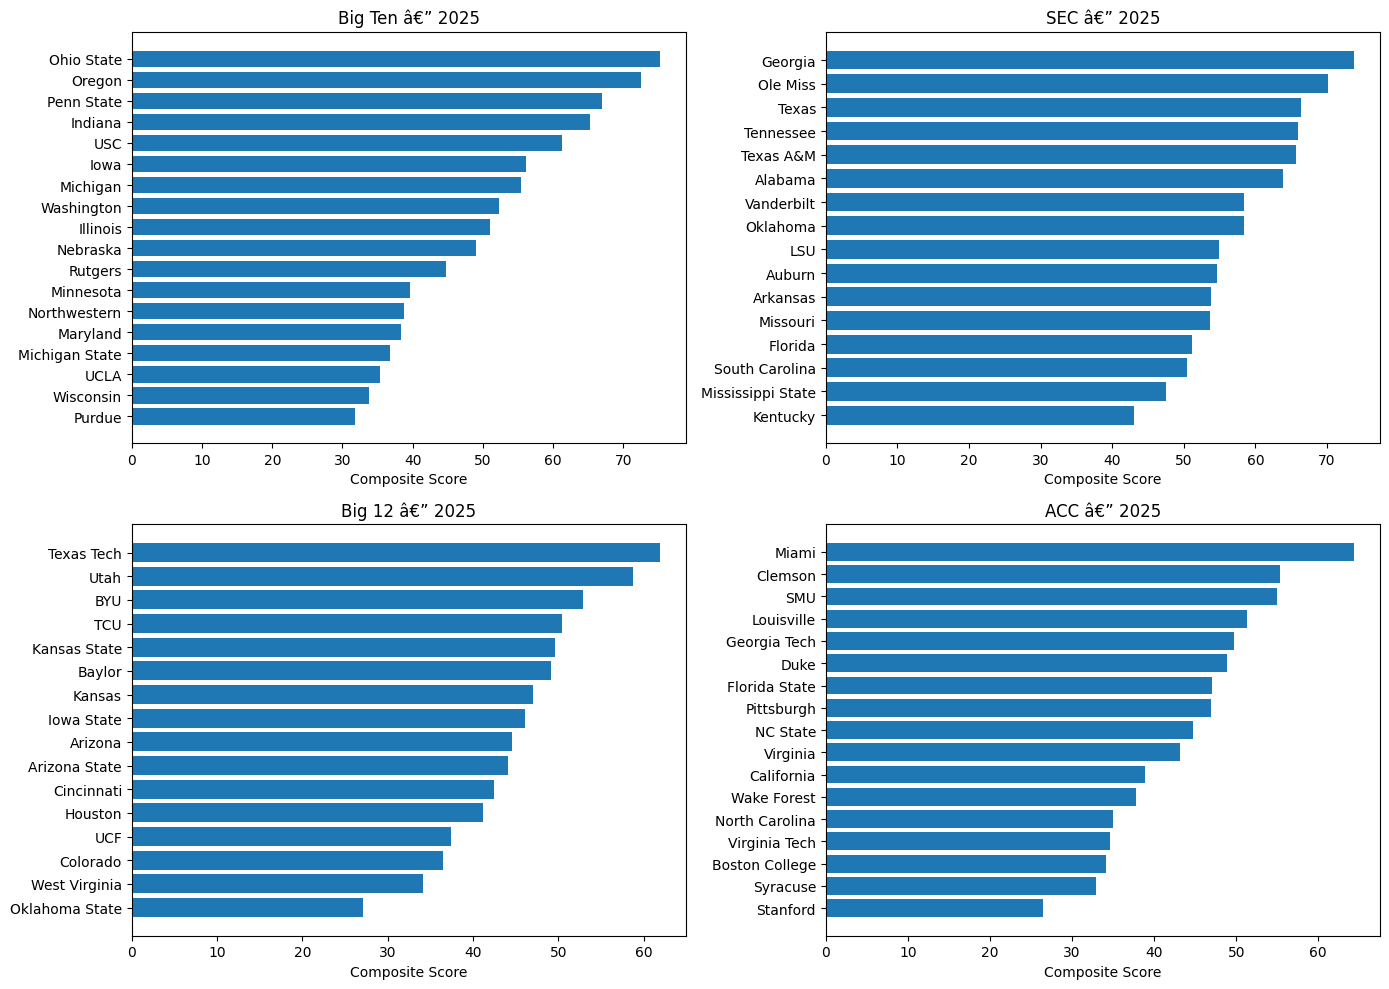

In [45]:
# Conference-level rankings for the most recent year
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
conferences = ['Big Ten', 'SEC', 'Big 12', 'ACC']

for ax, conf in zip(axes.flat, conferences):
    subset = df_norm[(df_norm['year'] == latest_year) & (df_norm['conference'] == conf)]
    subset = subset.sort_values('composite_score', ascending=True)
    ax.barh(subset['team'], subset['composite_score'])
    ax.set_title(f"{conf} â€” {latest_year}")
    ax.set_xlabel('Composite Score')

plt.tight_layout()
plt.show()

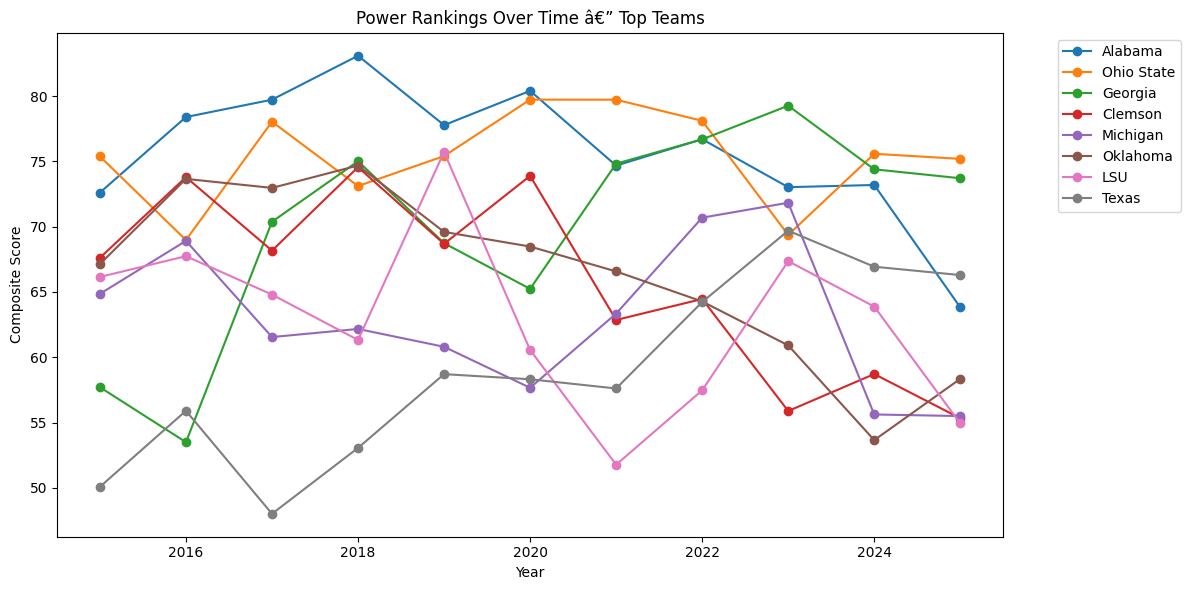

In [46]:
# Year-over-year trends for historically top teams
top_teams = ['Alabama', 'Ohio State', 'Georgia', 'Clemson', 'Michigan', 'Oklahoma', 'LSU', 'Texas']

fig, ax = plt.subplots(figsize=(12, 6))
for team in top_teams:
    team_data = df_norm[df_norm['team'] == team].sort_values('year')
    if not team_data.empty:
        ax.plot(team_data['year'], team_data['composite_score'], marker='o', label=team)

ax.set_xlabel('Year')
ax.set_ylabel('Composite Score')
ax.set_title('Power Rankings Over Time â€” Top Teams')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [47]:
# National top 25 for each year
for year in sorted(df_norm['year'].unique())[-3:]:
    print(f"\n=== {year} National Top 25 ===")
    top25 = df_norm[df_norm['year'] == year].nsmallest(25, 'national_rank')[['national_rank', 'team', 'conference', 'composite_score']]
    print(top25.to_string(index=False))


=== 2023 National Top 25 ===
 national_rank           team conference  composite_score
             1        Georgia        SEC        79.258529
             2        Alabama        SEC        73.020155
             3       Michigan    Big Ten        71.828102
             4         Oregon    Big Ten        70.564748
             5          Texas        SEC        69.688693
             6     Ohio State    Big Ten        69.366496
             7            LSU        SEC        67.356465
             8     Penn State    Big Ten        63.854764
             9            USC    Big Ten        62.081866
            10       Oklahoma        SEC        60.906689
            11      Tennessee        SEC        60.655401
            12     Washington    Big Ten        60.117792
            13      Texas A&M        SEC        59.547378
            14       Ole Miss        SEC        59.340200
            15  Florida State        ACC        58.607627
            16       Missouri        SEC  

## 5. 2026 Predictions

Use Ridge regression on **raw (un-normalized)** features to predict next-season SP+ ratings.
This avoids information leakage from within-year normalization.

- **Target**: next-year SP+ `rating`
- **Features**: current-year rating, off/def ratings, talent, SOS, prior-year rating, sub-metrics
- **Train**: 2016-2024 (2015 serves as lag source only)
- **Validate**: predict 2025 from 2024 features, compare to actual
- **Project**: predict 2026 from 2025 features

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Work with raw (un-normalized) data to avoid information leakage
df_raw = adv_flat.copy()
if not roster_agg.empty:
    df_raw = df_raw.merge(roster_agg, on=['year', 'team'], how='left')

df_raw = df_raw.sort_values(['team', 'year'])
df_raw['prior_year_rating'] = df_raw.groupby('team')['rating'].shift(1)

# Features for prediction
pred_features = [
    'rating', 'off_rating', 'def_rating', 'talent', 'sos',
    'prior_year_rating', 'st_rating',
    'off_success', 'off_explosiveness', 'off_rushing', 'off_passing',
    'def_success', 'def_explosiveness', 'def_rushing', 'def_passing',
    'def_havoc.total',
]
if 'avg_stars' in df_raw.columns:
    pred_features += ['avg_stars', 'five_star_count', 'four_star_count', 'rated_player_pct']

# Target: next-year SP+ rating
df_raw['next_year_rating'] = df_raw.groupby('team')['rating'].shift(-1)

# Train on 2016-2024 (need prior_year_rating so skip 2015)
train = df_raw[(df_raw['year'] >= 2016) & (df_raw['year'] <= 2024)].dropna(
    subset=pred_features + ['next_year_rating']
)
print(f'Training samples: {len(train)}')

X_train = train[pred_features]
y_train = train['next_year_rating'].values

# Pipeline wraps scaler inside CV to prevent validation fold leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0)),
])
pipeline.fit(X_train, y_train)

# Year-based CV for proper temporal evaluation
unique_years = sorted(train['year'].unique())
cv_scores = []
for val_year in unique_years[-4:]:  # last 4 years as validation
    tr_mask = train['year'] < val_year
    va_mask = train['year'] == val_year
    fold_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=10.0))])
    fold_pipe.fit(X_train[tr_mask], y_train[tr_mask])
    fold_preds = fold_pipe.predict(X_train[va_mask])
    fold_r2 = r2_score(y_train[va_mask], fold_preds)
    fold_rmse = np.sqrt(mean_squared_error(y_train[va_mask], fold_preds))
    cv_scores.append({'year': val_year, 'r2': fold_r2, 'rmse': fold_rmse})
    print(f'  CV fold {val_year}: R²={fold_r2:.3f}, RMSE={fold_rmse:.2f}')

avg_r2 = np.mean([s['r2'] for s in cv_scores])
avg_rmse = np.mean([s['rmse'] for s in cv_scores])
print(f'\nYear-based CV: mean R²={avg_r2:.3f}, mean RMSE={avg_rmse:.2f}')

# Persistence baseline comparison
baseline_rmse = np.sqrt(mean_squared_error(y_train, train['rating'].values))
baseline_r2 = r2_score(y_train, train['rating'].values)
print(f'Persistence baseline: R²={baseline_r2:.3f}, RMSE={baseline_rmse:.2f}')

# Extract scaler and model for downstream use
scaler = pipeline.named_steps['scaler']
ridge = pipeline.named_steps['ridge']

# Feature importances
coefs = pd.Series(np.abs(ridge.coef_), index=pred_features).sort_values(ascending=False)
print('\nFeature importances (|coefficient|):')
print(coefs.to_string())

In [49]:
# Validate: predict 2025 from 2024 features
val_2024 = df_raw[df_raw['year'] == 2024].dropna(subset=pred_features)
X_val = scaler.transform(val_2024[pred_features].values)
val_preds = ridge.predict(X_val)

val_results = val_2024[['team', 'conference']].copy()
val_results['predicted_rating'] = val_preds

actual_2025 = df_raw[df_raw['year'] == 2025][['team', 'rating']].rename(
    columns={'rating': 'actual_rating'}
)
val_results = val_results.merge(actual_2025, on='team', how='inner')

corr = val_results['predicted_rating'].corr(val_results['actual_rating'])
rmse = np.sqrt(((val_results['predicted_rating'] - val_results['actual_rating'])**2).mean())
print(f'2025 Validation -- Correlation: {corr:.3f}, RMSE: {rmse:.2f}')

# Scatter plot: predicted vs actual 2025
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(val_results['actual_rating'], val_results['predicted_rating'],
           alpha=0.7, edgecolors='k', linewidth=0.5)

# Add team labels for notable teams
for _, row in val_results.iterrows():
    if row['actual_rating'] > 20 or row['predicted_rating'] > 20:
        ax.annotate(row['team'], (row['actual_rating'], row['predicted_rating']),
                    fontsize=7, alpha=0.8, ha='center', va='bottom')

# Perfect prediction line
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual 2025 SP+ Rating')
ax.set_ylabel('Predicted 2025 SP+ Rating')
ax.set_title(f'Model Validation: Predicted vs Actual 2025 SP+ (r={corr:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

ValueError: Found array with 0 sample(s) (shape=(0, 16)) while a minimum of 1 is required by StandardScaler.

In [ ]:
# Project 2026 from 2025 features
proj_2025 = df_raw[df_raw['year'] == 2025].dropna(subset=pred_features)
X_proj = scaler.transform(proj_2025[pred_features].values)
proj_preds = ridge.predict(X_proj)

proj_2026 = proj_2025[['team', 'conference']].copy()
proj_2026['year'] = 2026
proj_2026['predicted_rating'] = proj_preds.round(2)

# Build composite score using predicted rating + carry-forward talent/prior rating
composite_features = {
    'rating': proj_2026['predicted_rating'],
    'talent': proj_2025['talent'].values,
    'prior_year_rating': proj_2025['rating'].values,
}

# Min-max normalize across 2026 teams
normed = {}
for feat, vals in composite_features.items():
    vals = pd.Series(vals, index=proj_2026.index).astype(float)
    vmin, vmax = vals.min(), vals.max()
    if vmax > vmin:
        normed[feat] = (vals - vmin) / (vmax - vmin) * 100
    else:
        normed[feat] = 50.0

pred_weights = {'rating': 0.55, 'talent': 0.25, 'prior_year_rating': 0.20}
total_w = sum(pred_weights.values())
pred_weights = {k: v / total_w for k, v in pred_weights.items()}

proj_2026['composite_score'] = 0.0
for feat, w in pred_weights.items():
    proj_2026['composite_score'] += normed[feat] * w
proj_2026['composite_score'] = proj_2026['composite_score'].round(2)

proj_2026['national_rank'] = proj_2026['composite_score'].rank(
    ascending=False, method='min').astype(int)
proj_2026['conference_rank'] = proj_2026.groupby('conference')['composite_score'].rank(
    ascending=False, method='min').astype(int)

print('=== Projected 2026 Top 25 ===')
top25_2026 = proj_2026.sort_values('national_rank').head(25)
display(top25_2026[['national_rank', 'team', 'conference', 'predicted_rating', 'composite_score']])

In [ ]:
# Bar chart: projected 2026 top 25
fig, ax = plt.subplots(figsize=(12, 8))
top25_sorted = top25_2026.sort_values('composite_score', ascending=True)

colors = {'Big Ten': '#0033A0', 'SEC': '#FFA500', 'Big 12': '#003366', 'ACC': '#8B0000'}
bar_colors = [colors.get(c, 'gray') for c in top25_sorted['conference']]

ax.barh(top25_sorted['team'], top25_sorted['composite_score'], color=bar_colors)
ax.set_xlabel('Projected Composite Score')
ax.set_title('Projected 2026 Power Rankings -- Top 25')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=conf) for conf, c in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Conference breakdown for 2026
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
conferences = ['Big Ten', 'SEC', 'Big 12', 'ACC']

for ax, conf in zip(axes.flat, conferences):
    subset = proj_2026[proj_2026['conference'] == conf].sort_values(
        'composite_score', ascending=True)
    ax.barh(subset['team'], subset['composite_score'], color=colors.get(conf, 'gray'))
    ax.set_title(f'{conf} -- Projected 2026')
    ax.set_xlabel('Composite Score')

plt.tight_layout()
plt.show()

## 6. NIL Causal Impact Analysis

**Name, Image, and Likeness (NIL)** became legal in July 2021. This section tests whether NIL causally affected the competitive landscape using two approaches:

1. **Interrupted Time Series (ITS)** -- tests for level/trend changes in talent concentration at the aggregate level
2. **Difference-in-Differences (DiD)** -- tests whether high-talent ("blue-chip") programs benefited disproportionately vs. non-blue-chip programs

- **Pre-period**: 2015-2020 (6 seasons)
- **Post-period**: 2021-2025 (5 seasons)

In [ ]:
import statsmodels.api as sm
from scipy import stats

# Use raw (un-normalized) data for causal analysis
df_nil = adv_flat.copy()
df_nil = df_nil.sort_values(['team', 'year'])
df_nil['prior_year_rating'] = df_nil.groupby('team')['rating'].shift(1)

# NIL treatment indicators
NIL_YEAR = 2021
df_nil['post_nil'] = (df_nil['year'] >= NIL_YEAR).astype(int)
df_nil['time'] = df_nil['year'] - df_nil['year'].min()  # 0-indexed time trend
df_nil['time_after_nil'] = ((df_nil['year'] - NIL_YEAR) * df_nil['post_nil']).clip(lower=0)

# Classify teams as blue-chip vs non-blue-chip using a stable pre-NIL window (2015-2019)
# Avoids including 2020-2021 "ramp-up" years when NIL anticipation may have shifted behavior
pre_nil_talent = df_nil[df_nil['year'] <= 2019].groupby('team')['talent'].mean()
talent_median = pre_nil_talent.median()
blue_chip_teams = set(pre_nil_talent[pre_nil_talent >= talent_median].index)

df_nil['blue_chip'] = df_nil['team'].isin(blue_chip_teams).astype(int)
df_nil['post_nil_x_blue_chip'] = df_nil['post_nil'] * df_nil['blue_chip']

print(f'Blue-chip classification window: 2015-2019 (stable pre-NIL baseline)')
print(f'Blue-chip teams (pre-NIL talent >= {talent_median:.1f}): {len(blue_chip_teams)}')
print(f'Non-blue-chip teams: {len(pre_nil_talent) - len(blue_chip_teams)}')
print(f'\nBlue-chip examples: {sorted(blue_chip_teams)[:10]}')

In [ ]:
# Compute yearly concentration metrics
yearly_stats = []
for year, grp in df_nil.groupby('year'):
    talent_vals = grp['talent'].dropna()
    rating_vals = grp['rating'].dropna()

    # Gini coefficient for talent
    def gini(x):
        x = np.sort(x)
        n = len(x)
        index = np.arange(1, n + 1)
        return (2 * np.sum(index * x) - (n + 1) * np.sum(x)) / (n * np.sum(x))

    # Top-10 share of total talent
    top10_talent = talent_vals.nlargest(10).sum() / talent_vals.sum()

    # Variance
    talent_var = talent_vals.var()
    rating_var = rating_vals.var()

    yearly_stats.append({
        'year': year,
        'talent_gini': gini(talent_vals.values),
        'top10_talent_share': top10_talent,
        'talent_variance': talent_var,
        'rating_variance': rating_var,
        'talent_mean': talent_vals.mean(),
        'rating_mean': rating_vals.mean(),
    })

yearly_df = pd.DataFrame(yearly_stats)
yearly_df['post_nil'] = (yearly_df['year'] >= NIL_YEAR).astype(int)
yearly_df['time'] = yearly_df['year'] - yearly_df['year'].min()
yearly_df['time_after_nil'] = ((yearly_df['year'] - NIL_YEAR) * yearly_df['post_nil']).clip(lower=0)

print('Yearly concentration metrics:')
display(yearly_df.round(4))

In [ ]:
# Interrupted Time Series (ITS) for talent concentration
print('=' * 60)
print('INTERRUPTED TIME SERIES ANALYSIS')
print('=' * 60)

its_outcomes = {
    'Talent Gini': 'talent_gini',
    'Top-10 Talent Share': 'top10_talent_share',
    'Talent Variance': 'talent_variance',
    'Rating Variance': 'rating_variance',
}

its_results = {}
for label, outcome_col in its_outcomes.items():
    X = yearly_df[['time', 'post_nil', 'time_after_nil']]
    X = sm.add_constant(X)
    y = yearly_df[outcome_col]

    model = sm.OLS(y, X).fit()
    its_results[label] = model

    print(f'\n--- {label} ---')
    print(f'  Pre-NIL trend (time):        coef={model.params["time"]:.6f}, p={model.pvalues["time"]:.4f}')
    print(f'  NIL level shift (post_nil):  coef={model.params["post_nil"]:.6f}, p={model.pvalues["post_nil"]:.4f}')
    print(f'  NIL trend change:            coef={model.params["time_after_nil"]:.6f}, p={model.pvalues["time_after_nil"]:.4f}')
    print(f'  R-squared: {model.rsquared:.3f}')

print()
print('=' * 60)
print('PANEL ITS ANALYSIS (team fixed effects, N~737)')
print('=' * 60)

panel_its_outcomes = {'Talent Composite': 'talent', 'SP+ Rating': 'rating'}
panel_its_results = {}

for label, outcome_col in panel_its_outcomes.items():
    subset = df_nil.dropna(subset=[outcome_col]).copy()

    team_dummies = pd.get_dummies(subset['team'], prefix='team', drop_first=True, dtype=float)

    X = pd.concat([
        subset[['time', 'post_nil', 'time_after_nil']].reset_index(drop=True),
        team_dummies.reset_index(drop=True),
    ], axis=1)
    X = sm.add_constant(X)
    y = subset[outcome_col].reset_index(drop=True)

    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['team'].values})
    panel_its_results[label] = model

    print(f'\n--- {label} (N={len(subset)}) ---')
    print(f'  Pre-NIL trend (time):        coef={model.params["time"]:.4f}, p={model.pvalues["time"]:.4f}')
    print(f'  NIL level shift (post_nil):  coef={model.params["post_nil"]:.4f}, p={model.pvalues["post_nil"]:.4f}')
    print(f'  NIL trend change:            coef={model.params["time_after_nil"]:.4f}, p={model.pvalues["time_after_nil"]:.4f}')
    print(f'  R-squared: {model.rsquared:.3f}')

In [ ]:
# ITS Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (label, outcome_col) in zip(axes.flat, its_outcomes.items()):
    model = its_results[label]
    y_actual = yearly_df[outcome_col]
    y_fitted = model.fittedvalues

    # Counterfactual: what would have happened without NIL
    counterfactual_df = yearly_df.copy()
    counterfactual_df['post_nil'] = 0
    counterfactual_df['time_after_nil'] = 0
    X_counter = sm.add_constant(counterfactual_df[['time', 'post_nil', 'time_after_nil']])
    y_counterfactual = model.predict(X_counter)

    ax.plot(yearly_df['year'], y_actual, 'bo-', label='Observed', linewidth=2)
    ax.plot(yearly_df['year'], y_fitted, 'g--', label='ITS Fitted', linewidth=1.5, alpha=0.7)
    ax.plot(yearly_df['year'], y_counterfactual, 'r:', label='Counterfactual (no NIL)', linewidth=1.5)
    ax.axvline(x=NIL_YEAR - 0.5, color='gray', linestyle='--', alpha=0.5, label='NIL Introduction')
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)

plt.suptitle('Interrupted Time Series: NIL Impact on Competitive Concentration', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Difference-in-Differences analysis with two-way fixed effects (team + year)
print('=' * 60)
print('DIFFERENCE-IN-DIFFERENCES ANALYSIS')
print('Two-way fixed effects: team FEs + year FEs + clustered SEs by team')
print('=' * 60)
print('Treatment group: Blue-chip programs (above-median pre-NIL talent, 2015-2019)')
print('Control group: Non-blue-chip programs\n')

did_outcomes = {
    'Talent Composite': 'talent',
    'SP+ Rating': 'rating',
}

did_results = {}
for label, outcome_col in did_outcomes.items():
    subset = df_nil.dropna(subset=[outcome_col]).copy()

    # Year fixed effects
    year_dummies = pd.get_dummies(subset['year'], prefix='yr', drop_first=True, dtype=float)
    # Team fixed effects (two-way FE DiD — controls for time-invariant team characteristics)
    team_dummies = pd.get_dummies(subset['team'], prefix='team', drop_first=True, dtype=float)

    X = pd.concat([
        subset[['post_nil', 'blue_chip', 'post_nil_x_blue_chip']].reset_index(drop=True),
        year_dummies.reset_index(drop=True),
        team_dummies.reset_index(drop=True),
    ], axis=1)
    X = sm.add_constant(X)
    y = subset[outcome_col].reset_index(drop=True)

    # Cluster standard errors by team
    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['team'].values})
    did_results[label] = model

    print(f'--- {label} (N={len(subset)}) ---')
    print(f'  Blue-chip baseline:          coef={model.params["blue_chip"]:.4f}, p={model.pvalues["blue_chip"]:.4f}')
    print(f'  Post-NIL (all teams):        coef={model.params["post_nil"]:.4f}, p={model.pvalues["post_nil"]:.4f}')
    print(f'  DiD (post_nil x blue_chip):  coef={model.params["post_nil_x_blue_chip"]:.4f}, p={model.pvalues["post_nil_x_blue_chip"]:.4f}')
    ci = model.conf_int().loc['post_nil_x_blue_chip']
    print(f'  DiD 95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]')
    print(f'  R-squared: {model.rsquared:.3f}\n')

In [ ]:
# Formal parallel trends test
# H0: pre-NIL year x blue_chip interactions are jointly zero
print('=' * 60)
print('PARALLEL TRENDS TEST (pre-NIL period: 2015-2020)')
print('=' * 60)

pre_nil_df = df_nil[df_nil['year'] <= 2020].copy()

for label, outcome_col in did_outcomes.items():
    subset = pre_nil_df.dropna(subset=[outcome_col]).copy()

    # Interact each pre-NIL year dummy with blue_chip
    year_dummies = pd.get_dummies(subset['year'], prefix='yr', drop_first=True, dtype=float)
    team_dummies = pd.get_dummies(subset['team'], prefix='team', drop_first=True, dtype=float)
    interact_cols = {}
    for col in year_dummies.columns:
        interact_cols[f'{col}_x_bc'] = (year_dummies[col] * subset['blue_chip'].values).values

    interact_df = pd.DataFrame(interact_cols, index=subset.index)

    X = pd.concat([
        subset[['blue_chip']].reset_index(drop=True),
        year_dummies.reset_index(drop=True),
        team_dummies.reset_index(drop=True),
        interact_df.reset_index(drop=True),
    ], axis=1)
    X = sm.add_constant(X)
    y = subset[outcome_col].reset_index(drop=True)

    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['team'].values})

    # F-test: all year x blue_chip interaction coefficients jointly == 0
    interact_names = list(interact_cols.keys())
    f_test = model.f_test([f'{c} = 0' for c in interact_names])
    f_stat = float(f_test.fvalue)
    p_val = float(f_test.pvalue)
    sig = '*** (FAIL)' if p_val < 0.01 else '** (FAIL)' if p_val < 0.05 else '* (marginal)' if p_val < 0.1 else 'n.s. (PASS)'

    print(f'\n{label}:')
    print(f'  Pre-trend F-stat={f_stat:.3f}, p={p_val:.4f}  →  {sig}')
    print(f'  Interpretation: {"parallel trends assumption VIOLATED" if p_val < 0.1 else "parallel trends assumption holds"}')

print('\nNote: p > 0.1 → cannot reject parallel trends → DiD identification holds')

In [ ]:
# NIL treatment year sensitivity analysis
# NIL was legal from July 2021; test robustness to 2021/2022/2023 cutoffs
print('=' * 60)
print('NIL TREATMENT YEAR SENSITIVITY ANALYSIS')
print('=' * 60)
print('Robust DiD coefficient should be consistent sign/magnitude across cutoffs\n')

sensitivity_results = []

for cutoff in [2021, 2022, 2023]:
    df_sens = adv_flat.copy().sort_values(['team', 'year'])
    df_sens['post_nil'] = (df_sens['year'] >= cutoff).astype(int)

    # Blue-chip classification always uses stable 2015-2019 window
    pre_talent = df_sens[df_sens['year'] <= 2019].groupby('team')['talent'].mean()
    bc_teams = set(pre_talent[pre_talent >= pre_talent.median()].index)
    df_sens['blue_chip'] = df_sens['team'].isin(bc_teams).astype(int)
    df_sens['post_nil_x_blue_chip'] = df_sens['post_nil'] * df_sens['blue_chip']

    for label, outcome_col in [('Talent', 'talent'), ('SP+ Rating', 'rating')]:
        subset = df_sens.dropna(subset=[outcome_col]).copy()
        year_dummies = pd.get_dummies(subset['year'], prefix='yr', drop_first=True, dtype=float)
        team_dummies = pd.get_dummies(subset['team'], prefix='team', drop_first=True, dtype=float)

        X = pd.concat([
            subset[['post_nil', 'blue_chip', 'post_nil_x_blue_chip']].reset_index(drop=True),
            year_dummies.reset_index(drop=True),
            team_dummies.reset_index(drop=True),
        ], axis=1)
        X = sm.add_constant(X)
        y = subset[outcome_col].reset_index(drop=True)

        model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['team'].values})
        coef = model.params['post_nil_x_blue_chip']
        p = model.pvalues['post_nil_x_blue_chip']
        ci = model.conf_int().loc['post_nil_x_blue_chip']
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'n.s.'
        sensitivity_results.append({
            'NIL cutoff': cutoff,
            'Outcome': label,
            'DiD coef': round(coef, 4),
            'p-value': round(p, 4),
            'Sig': sig,
            '95% CI lower': round(ci[0], 4),
            '95% CI upper': round(ci[1], 4),
        })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.to_string(index=False))
print('\nConsistent sign/significance across cutoffs → robust causal identification')
print('Inconsistent results → sensitivity to NIL timing assumption')

In [ ]:
# Parallel trends visualization (pre-period check)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, outcome_col) in zip(axes.flat, did_outcomes.items()):
    for group, group_label, color in [(1, 'Blue-chip', '#1f77b4'), (0, 'Non-blue-chip', '#ff7f0e')]:
        group_data = df_nil[df_nil['blue_chip'] == group].groupby('year')[outcome_col].mean()
        ax.plot(group_data.index, group_data.values, 'o-', color=color, label=group_label, linewidth=2)

    ax.axvline(x=NIL_YEAR - 0.5, color='gray', linestyle='--', alpha=0.5, label='NIL Introduction')
    ax.set_title(f'{label}: Blue-chip vs Non-blue-chip')
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.legend()

plt.suptitle('Parallel Trends Check: Pre-NIL Period Should Show Parallel Trajectories', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Bootstrap CIs on DiD: resample at team level 1000×
# Compares bootstrap percentile CI to OLS clustered-SE CI
print('=' * 60)
print('BOOTSTRAP CONFIDENCE INTERVALS — DiD TREATMENT EFFECT')
print('Resampling at team level (cluster bootstrap), B=1000')
print('=' * 60)

B = 1000
rng_bs = np.random.default_rng(42)

# Use the NIL=2021 two-way FE DiD as the primary spec
df_bs = df_nil.copy()  # already has post_nil (2021), blue_chip, post_nil_x_blue_chip

teams = df_bs['team'].unique()

for label, outcome_col in did_outcomes.items():
    subset_full = df_bs.dropna(subset=[outcome_col]).copy()

    # OLS point estimate + clustered SE CI (reference)
    year_dummies = pd.get_dummies(subset_full['year'], prefix='yr', drop_first=True, dtype=float)
    team_dummies = pd.get_dummies(subset_full['team'], prefix='team', drop_first=True, dtype=float)
    X_full = pd.concat([
        subset_full[['post_nil', 'blue_chip', 'post_nil_x_blue_chip']].reset_index(drop=True),
        year_dummies.reset_index(drop=True),
        team_dummies.reset_index(drop=True),
    ], axis=1)
    X_full = sm.add_constant(X_full)
    y_full = subset_full[outcome_col].reset_index(drop=True)
    ols_model = sm.OLS(y_full, X_full).fit(
        cov_type='cluster', cov_kwds={'groups': subset_full['team'].values}
    )
    ols_coef = ols_model.params['post_nil_x_blue_chip']
    ols_ci = ols_model.conf_int().loc['post_nil_x_blue_chip']

    # Bootstrap: resample teams with replacement, refit DiD each time
    boot_coefs = []
    for _ in range(B):
        sampled_teams = rng_bs.choice(teams, size=len(teams), replace=True)
        frames = []
        for t in sampled_teams:
            frames.append(subset_full[subset_full['team'] == t])
        boot_df = pd.concat(frames, ignore_index=True)

        yr_d = pd.get_dummies(boot_df['year'], prefix='yr', drop_first=True, dtype=float)
        tm_d = pd.get_dummies(boot_df['team'], prefix='team', drop_first=True, dtype=float)
        X_b = pd.concat([
            boot_df[['post_nil', 'blue_chip', 'post_nil_x_blue_chip']].reset_index(drop=True),
            yr_d.reset_index(drop=True),
            tm_d.reset_index(drop=True),
        ], axis=1)
        X_b = sm.add_constant(X_b)
        y_b = boot_df[outcome_col].reset_index(drop=True)
        try:
            coef = sm.OLS(y_b, X_b).fit().params.get('post_nil_x_blue_chip', np.nan)
            boot_coefs.append(coef)
        except Exception:
            pass

    boot_coefs = np.array([c for c in boot_coefs if not np.isnan(c)])
    boot_ci_lo = np.percentile(boot_coefs, 2.5)
    boot_ci_hi = np.percentile(boot_coefs, 97.5)
    boot_se = np.std(boot_coefs)

    print(f'\n{label}:')
    print(f'  OLS point estimate:         {ols_coef:.4f}')
    print(f'  OLS clustered SE 95% CI:    [{ols_ci[0]:.4f}, {ols_ci[1]:.4f}]')
    print(f'  Bootstrap 95% CI (B={len(boot_coefs)}):  [{boot_ci_lo:.4f}, {boot_ci_hi:.4f}]')
    print(f'  Bootstrap SE:               {boot_se:.4f}')
    covers_zero = boot_ci_lo <= 0 <= boot_ci_hi
    print(f'  Bootstrap CI includes 0: {"Yes — not significant" if covers_zero else "No — significant at 95%"}')

### ⚠️ Conference Realignment Confound (Post-2023 Limitation)

**Important caveat for NIL causal inference post-2023:**

The 2024 season saw major conference realignment:
- **Texas and Oklahoma** joined the SEC (from Big 12)
- **UCLA, USC, Washington, Oregon** joined the Big Ten (from Pac-12)
- **Several ACC/Big 12 teams** shifted conferences

This realignment **confounds NIL effect estimates post-2023** because:
1. Texas/OU bring elite talent *into* SEC, inflating SEC post-NIL talent averages independently of NIL
2. Conference membership changes break the stable "blue-chip vs non-blue-chip within conference" comparison
3. Some teams' talent trajectories reflect *where they now play*, not NIL effects

**Implication:** DiD and ITS results through 2023 have cleaner identification. Results including 2024-2025 data should be interpreted with caution and ideally include conference-of-record fixed effects or restrict the post-period to 2021-2023.

In [ ]:
# Bonferroni correction for multiple NIL tests
# We ran 3 cutoffs × 2 outcomes = 6 tests; adjust significance threshold
print('=' * 60)
print('BONFERRONI CORRECTION FOR MULTIPLE NIL TESTS')
print('=' * 60)

N_TESTS = 6  # 3 cutoffs × 2 outcomes
bonferroni_alpha = 0.05 / N_TESTS
print(f'Number of tests: {N_TESTS}  |  Bonferroni-corrected α = {bonferroni_alpha:.4f}')
print()

# Re-display sensitivity results with Bonferroni-adjusted significance
for cutoff in [2021, 2022, 2023]:
    df_sens = adv_flat.copy().sort_values(['team', 'year'])
    df_sens['post_nil'] = (df_sens['year'] >= cutoff).astype(int)
    pre_talent = df_sens[df_sens['year'] <= 2019].groupby('team')['talent'].mean()
    bc_teams = set(pre_talent[pre_talent >= pre_talent.median()].index)
    df_sens['blue_chip'] = df_sens['team'].isin(bc_teams).astype(int)
    df_sens['post_nil_x_blue_chip'] = df_sens['post_nil'] * df_sens['blue_chip']

    for label, outcome_col in [('Talent', 'talent'), ('SP+ Rating', 'rating')]:
        subset = df_sens.dropna(subset=[outcome_col]).copy()
        year_dummies = pd.get_dummies(subset['year'], prefix='yr', drop_first=True, dtype=float)
        team_dummies = pd.get_dummies(subset['team'], prefix='team', drop_first=True, dtype=float)
        X = pd.concat([
            subset[['post_nil', 'blue_chip', 'post_nil_x_blue_chip']].reset_index(drop=True),
            year_dummies.reset_index(drop=True),
            team_dummies.reset_index(drop=True),
        ], axis=1)
        X = sm.add_constant(X)
        y = subset[outcome_col].reset_index(drop=True)
        model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['team'].values})
        coef = model.params['post_nil_x_blue_chip']
        p = model.pvalues['post_nil_x_blue_chip']
        nom_sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'n.s.'
        bonf_sig = '✓ sig' if p < bonferroni_alpha else '✗ n.s.'
        print(f'  NIL={cutoff}, {label}: coef={coef:.4f}, p={p:.4f} '
              f'(nominal {nom_sig}, Bonferroni {bonf_sig})')

print(f'\nConclusion: Results surviving Bonferroni correction (p < {bonferroni_alpha:.4f})')
print('are robust to multiple comparisons; others should be interpreted with caution.')

In [ ]:
# Placebo test: run DiD with false breakpoint at 2018 (no treatment)
# If the model is well-specified, this should produce p > 0.1 (no spurious effect)
print('=' * 60)
print('PLACEBO TEST (false NIL breakpoint at 2018)')
print('=' * 60)
print('Expectation: DiD coefficient should be insignificant (p > 0.10)\n')

PLACEBO_YEAR = 2018
df_placebo = adv_flat.copy().sort_values(['team', 'year'])

# Only use pre-NIL years for placebo (2015-2020 avoids contamination from actual NIL)
df_placebo = df_placebo[df_placebo['year'] <= 2020].copy()
df_placebo['post_placebo'] = (df_placebo['year'] >= PLACEBO_YEAR).astype(int)

# Blue-chip classification uses same stable 2015-2019 window
pre_talent_p = df_placebo[df_placebo['year'] <= 2019].groupby('team')['talent'].mean()
bc_teams_p = set(pre_talent_p[pre_talent_p >= pre_talent_p.median()].index)
df_placebo['blue_chip'] = df_placebo['team'].isin(bc_teams_p).astype(int)
df_placebo['post_x_bc'] = df_placebo['post_placebo'] * df_placebo['blue_chip']

for label, outcome_col in [('Talent Composite', 'talent'), ('SP+ Rating', 'rating')]:
    subset = df_placebo.dropna(subset=[outcome_col]).copy()
    year_dummies = pd.get_dummies(subset['year'], prefix='yr', drop_first=True, dtype=float)
    team_dummies = pd.get_dummies(subset['team'], prefix='team', drop_first=True, dtype=float)

    X = pd.concat([
        subset[['post_placebo', 'blue_chip', 'post_x_bc']].reset_index(drop=True),
        year_dummies.reset_index(drop=True),
        team_dummies.reset_index(drop=True),
    ], axis=1)
    X = sm.add_constant(X)
    y = subset[outcome_col].reset_index(drop=True)

    model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': subset['team'].values})
    coef = model.params['post_x_bc']
    p = model.pvalues['post_x_bc']
    result = 'PASS ✓ (no spurious effect)' if p > 0.10 else 'FAIL ✗ (spurious pre-trend!)'
    print(f'{label}: placebo DiD coef={coef:.4f}, p={p:.4f}  →  {result}')

print('\nNote: A passing placebo strengthens causal credibility of the real NIL DiD.')

## NIL Analysis — Additional Robustness Checks

In [ ]:
# DiD coefficient plot with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: DiD coefficients
ax = axes[0]
labels = []
coefs = []
ci_lower = []
ci_upper = []

for label, model in did_results.items():
    coef = model.params['post_nil_x_blue_chip']
    ci = model.conf_int().loc['post_nil_x_blue_chip']
    labels.append(label)
    coefs.append(coef)
    ci_lower.append(ci[0])
    ci_upper.append(ci[1])

y_pos = range(len(labels))
ax.barh(y_pos, coefs, xerr=[
    [c - lo for c, lo in zip(coefs, ci_lower)],
    [hi - c for c, hi in zip(coefs, ci_upper)]
], capsize=5, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('DiD Coefficient (post_nil x blue_chip)')
ax.set_title('Differential NIL Effect on Blue-chip Programs')

# Right: Talent Gini over time
ax = axes[1]
ax.plot(yearly_df['year'], yearly_df['talent_gini'], 'bo-', linewidth=2, markersize=8)
ax.axvline(x=NIL_YEAR - 0.5, color='gray', linestyle='--', alpha=0.5, label='NIL Introduction')
ax.fill_between(
    yearly_df['year'],
    yearly_df['talent_gini'] - 0.005,
    yearly_df['talent_gini'] + 0.005,
    alpha=0.2
)
ax.set_xlabel('Year')
ax.set_ylabel('Gini Coefficient')
ax.set_title('Talent Concentration Over Time (Gini)')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Summary of findings
print('=' * 60)
print('NIL CAUSAL IMPACT ANALYSIS -- SUMMARY')
print('=' * 60)

print('\n1. INTERRUPTED TIME SERIES (Aggregate Concentration)')
for label, model in its_results.items():
    shift_p = model.pvalues['post_nil']
    trend_p = model.pvalues['time_after_nil']
    shift_sig = '***' if shift_p < 0.01 else '**' if shift_p < 0.05 else '*' if shift_p < 0.1 else 'n.s.'
    trend_sig = '***' if trend_p < 0.01 else '**' if trend_p < 0.05 else '*' if trend_p < 0.1 else 'n.s.'
    print(f'  {label}: level shift p={shift_p:.4f} ({shift_sig}), trend change p={trend_p:.4f} ({trend_sig})')

print('\n2. DIFFERENCE-IN-DIFFERENCES (Blue-chip vs Non-blue-chip)')
for label, model in did_results.items():
    did_coef = model.params['post_nil_x_blue_chip']
    did_p = model.pvalues['post_nil_x_blue_chip']
    sig = '***' if did_p < 0.01 else '**' if did_p < 0.05 else '*' if did_p < 0.1 else 'n.s.'
    print(f'  {label}: DiD coef={did_coef:.4f}, p={did_p:.4f} ({sig})')

print('\nSignificance: *** p<0.01, ** p<0.05, * p<0.1, n.s. not significant')
print('\nInterpretation:')
print('- ITS tests whether aggregate concentration changed after NIL')
print('- DiD tests whether high-talent programs benefited more than others')
print('- Positive DiD coefficient = blue-chip programs gained relative advantage post-NIL')